In [1]:
import uproot
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/tmlinare/Lund_tagging/lundtoptagger")
from plotting.utils_plots_matplotlib import hist_with_errors

In [2]:
score_files_paths = [
    "/home/tmlinare/Lund_tagging/lundtoptagger_data_rcif/scores/v2.1.5_GN2X_0.25percent_hypatia_run_31-32/*.root"
]
tree_name = "FlatSubstructureJetTree"

In [3]:
dsid_weight_map = {
    364703: 12823.94988,
    364704: 5081.45927,
    364705: 3017.75098,
    364706: 4371.00012,
    364707: 2349.98631,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
}

In [4]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]
data = uproot.concatenate(score_files_paths_with_trees)

In [5]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(data)

<Array [{fjet_m: 85.1, fjet_pt: 330, ...}, ...] type='848050 * {fjet_m: flo...'>

In [6]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 47139
Background jets: 800911
Total: 848050


In [7]:
# weights = data["fjet_weight_pt"]
# weights = np.ones_like(data["fjet_weight_pt"])
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

In [8]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [9]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN2X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN2X_pqcd"],
        data["GN2X_phbb"],
        data["GN2X_phcc"],
        data["GN2X_ptop"],
        step=0.01
    )
    print(f"GN2X best AUC: {GN2X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN2X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [10]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05
denoms = fhbb * data["GN2X_phbb"] + fhcc * data["GN2X_phcc"] + (1 - fhbb - fhcc) *  data["GN2X_pqcd"]
gn2x_scores = np.log(data["GN2X_ptop"] / denoms)

In [11]:
models = {
    "LundNet": {
        "scores": data["fjet_LundNet_score"]
    },
    "LundNet+GN2X": {
        "scores": data["fjet_LundNet_plus_GN2X_score"]
    },
    "GN2X": {
        "scores": gn2x_scores
    }
}

# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

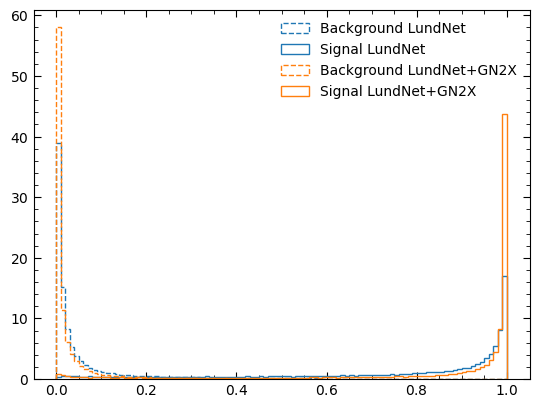

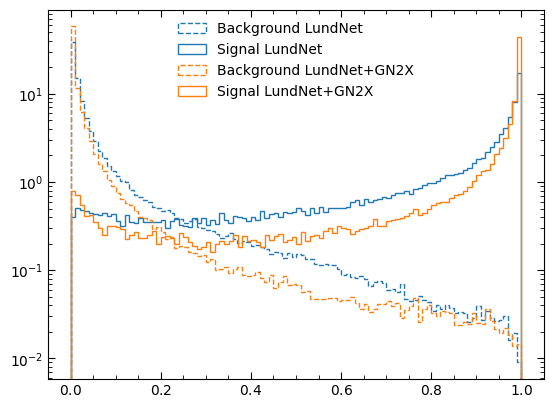

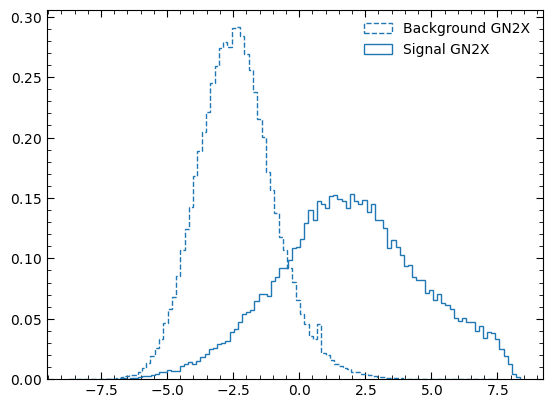

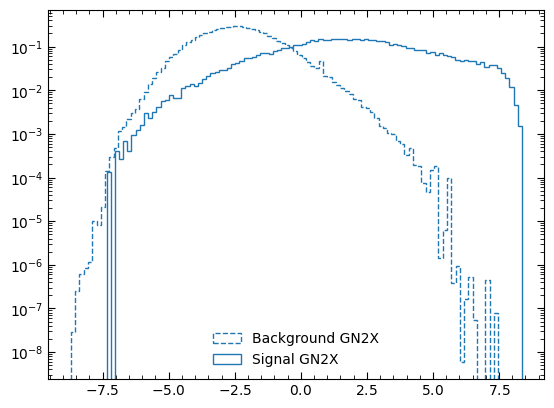

In [12]:
# Extract scores and labels
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

selected_models = ["LundNet", "LundNet+GN2X"]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

selected_models = ["GN2X"]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

In [13]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet: 0.8957899808883667
50% signal efficiency threshold for LundNet+GN2X: 0.983116090297699
50% signal efficiency threshold for GN2X: 1.875063503820677


In [14]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

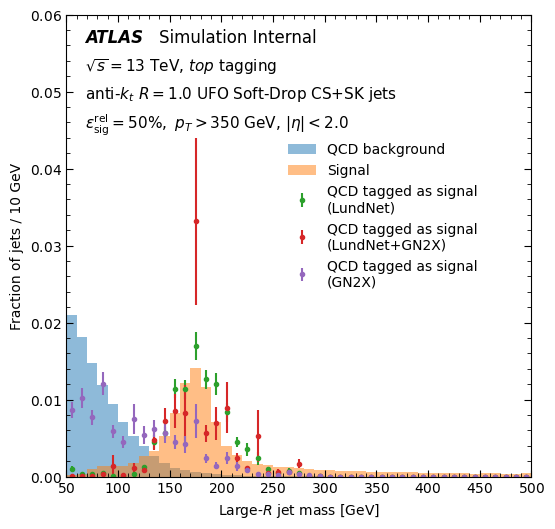

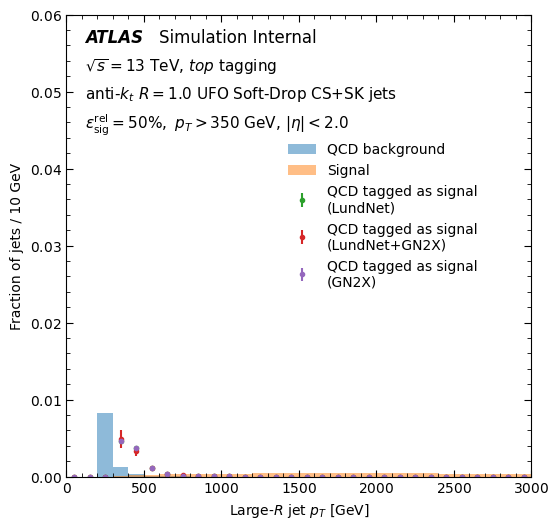

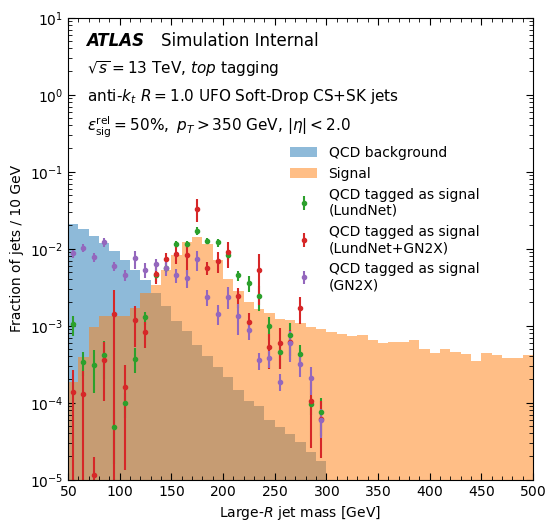

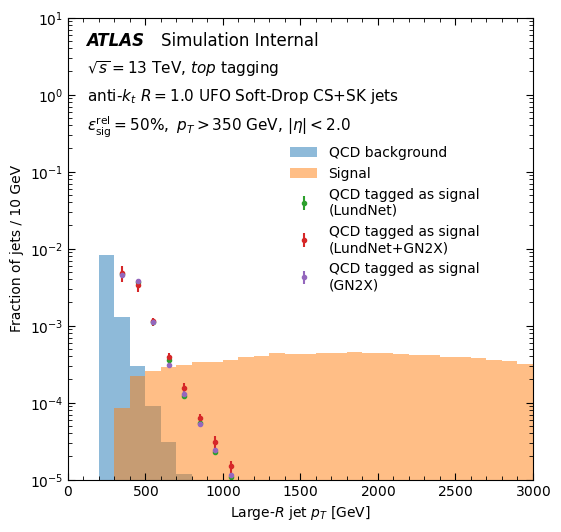

In [15]:
selected_models = models.keys()  # Use all models for now
selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
plot_signal_after_tagging = False

plot_params = {
    "lin": {
        "yscale": "linear",
        "ylim": (0, 0.06),
    },
    "log": {
        "yscale": "log",
        "ylim": (1e-5, 10),
    }
}

for params in plot_params.values():
    for var in var_params:
        fig, ax = plt.subplots(figsize=(6, 6))

        var_data = data[var]
        hist_params = dict(
            bins = var_params[var]["bins"],
            range = var_params[var]["range"],
            density = True,
            # histtype = "step"
        )
        errorbar_params = dict(
            fmt='.',
        )
        plt.hist(var_data[labels==0], weights=weights[labels==0], label="QCD background", **hist_params, alpha=0.5)
        plt.hist(var_data[labels==1], weights=weights[labels==1], label="Signal",         **hist_params, alpha=0.5)

        for model in selected_models:
            tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]
            hist_with_errors(var_data[(labels==0) & tagged_as_signal & selection], weights=weights[(labels==0) & tagged_as_signal & selection], label=f"QCD tagged as signal\n({model})", **hist_params, **errorbar_params)
            if plot_signal_after_tagging:
                hist_with_errors(var_data[(labels==1) & tagged_as_signal & selection], weights=weights[(labels==1) & tagged_as_signal & selection], label=f"Signal tagged as signal\n({model})",     **hist_params, **errorbar_params)

        # Add ATLAS label
        atlas_label = r"ATLAS"
        atlas_sim = r"Simulation Internal"
        atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
        jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
        selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
        text_args = {"transform": ax.transAxes, "va": 'top'}
        ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
        ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
        ax.text(0.04, 0.91, atlas_info,     fontsize=11, **text_args)
        ax.text(0.04, 0.85, jet_info,       fontsize=11, **text_args)
        ax.text(0.04, 0.79, selection_info, fontsize=11, **text_args)

        plt.xlim(var_params[var]["range"])
        plt.xlabel(var_params[var]["title"])
        plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
        plt.yscale(params["yscale"])
        plt.ylim(params["ylim"])
        # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
        plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
        plt.show()

In [16]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]
m_min = 150
m_max = 200
pt_min = 350
eta_max = 2
cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (np.abs(eta) < eta_max)

y_truth_cuts = data["labels"][cuts]
weights_cuts = weights[cuts]

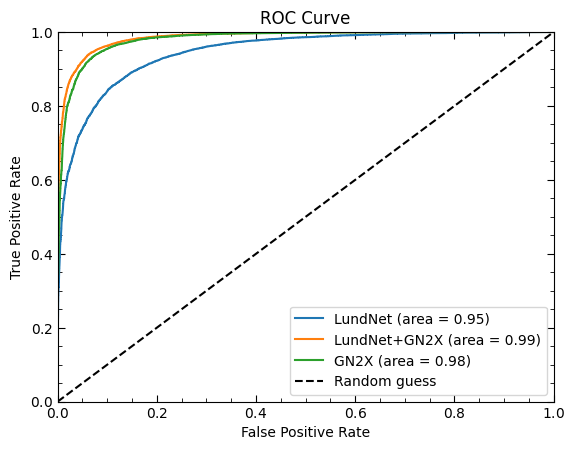

In [17]:
for trained_model in models:
    y_pred = models[trained_model]["scores"] if cuts is None else models[trained_model]["scores"][cuts]
    fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
    roc_auc = auc(fpr, tpr)

    models[trained_model]["fpr"] = fpr
    models[trained_model]["tpr"] = tpr

    plt.plot(fpr, tpr, label=f"{trained_model} (area = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

plt.title(f"{m_min} < m < {m_max} GeV, $p_T$ > {pt_min}, |$\eta$| < {eta_max}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend(loc="lower right")
# plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

/tmp/ipykernel_9178/976340202.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr, 1/fpr, label=f"{trained_model}")


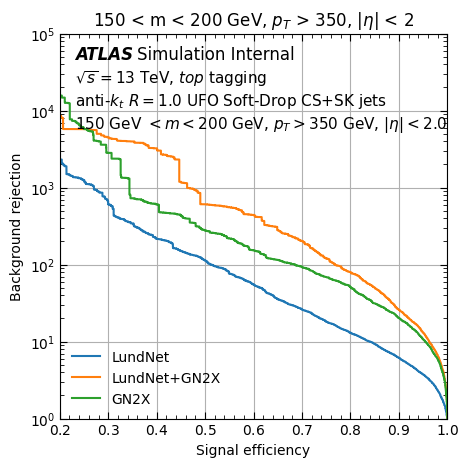

In [18]:
selected_models = models.keys()  # Use all models for now

fig, ax1 = plt.subplots(figsize=(5, 5))

for trained_model in selected_models:
    fpr = models[trained_model]["fpr"]
    tpr = models[trained_model]["tpr"]
    plt.plot(tpr, 1/fpr, label=f"{trained_model}")

plt.title(f"{m_min} < m < {m_max} GeV, $p_T$ > {pt_min}, |$\eta$| < {eta_max}")
plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection")
plt.xlim([0.2, 1])
plt.ylim([1, 1e5])
plt.yscale("log")
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")

# Add ATLAS label
atlas_label = r"ATLAS"
atlas_sim = r"Simulation Internal"
atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
selection_info = r"$150$ GeV $< m < 200$ GeV, $p_T > 350$ GeV, $| \eta | < 2.0$"
# selection_info = r"$m > 40$ GeV, $p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection
text_args = {"transform": ax1.transAxes, "va": 'top'}
ax1.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
ax1.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
ax1.text(0.04, 0.91, atlas_info,     fontsize=11, **text_args)
ax1.text(0.04, 0.85, jet_info,       fontsize=11, **text_args)
ax1.text(0.04, 0.79, selection_info, fontsize=11, **text_args)

plt.grid(True)
plt.show()